<a href="https://colab.research.google.com/github/nitin864/data_analysis_on_house_price_dataset/blob/main/ML_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from google.colab import files
uploaded = files.upload();
warnings.filterwarnings('ignore')

Saving train.csv to train (1).csv


In [13]:
#lodaing the dataset

In [14]:
df = pd.read_csv('train.csv');
df.head()          # First 5 rows
df.shape           # Rows and columns
df.info()          # Data types
df.describe()      # Statistical summary
df.isnull().sum()  # Missing values count
df.duplicated().sum()  # Duplicate rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

np.int64(0)

In [15]:
#Data_cleaning_and_preprocessing

In [16]:
#checking_missing_values
print(df.isnull().sum().sort_values(ascending=False).head(20))

#if 40% of data not available then droping the column
threshold = len(df) * 0.6
df = df.dropna(thresh=threshold, axis=1)

#meadian of numeric column
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

#filling_category column with their mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

#droping_duplicates
df.drop_duplicates(inplace=True)

#printing_missing_values
print("Missing values after cleaning:", df.isnull().sum().sum())
print("Final shape:", df.shape)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64
Missing values after cleaning: 0
Final shape: (1460, 75)


In [17]:
#Visualization 1 : Sale Price Distribution

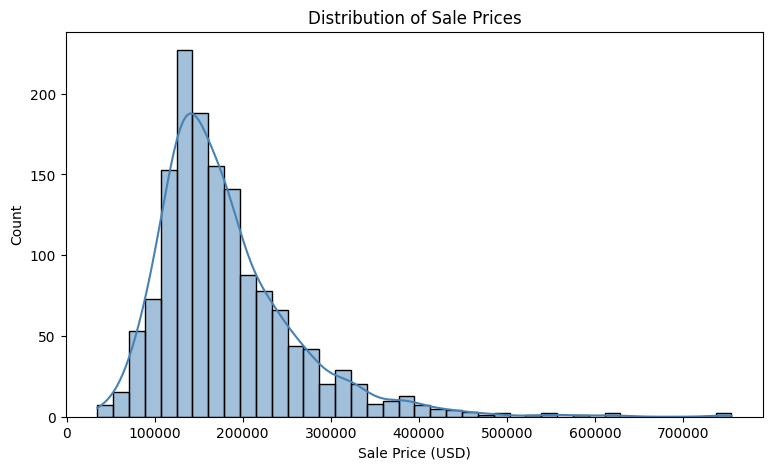

In [18]:
plt.figure(figsize=(9,5))
sns.histplot(df['SalePrice'], kde=True, color='steelblue', bins=40)
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price (USD)')
plt.ylabel('Count')
plt.show()

In [18]:
# Insights from 1st Visulalization: Most houses are priced between $100,000–$250,000. The distribution is right-skewed, meaning a few very expensive houses pull the average up.